# 🤖 Step 1: Setup Dependencies

In [1]:
!pip install torch torchvision faiss-cpu transformers pillow 
!pip install open_clip_torch==2.23.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 30.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 95.0 MB/s eta 0:00:00:00:0100:01
  Attempting un

In [2]:
!pip install --upgrade pip
!pip install transformers accelerate sentencepiece einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.0 MB/s eta 0:00:0000:010:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [3]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 117.8 MB/s  0:00:00m0:00:0100:01


# 🤖 Step 2: Use MEDCLIP model to embedding data and store in FAISS



In [4]:
# =========================================================
# ⚙️ Setup environment and paths (User Provided)
# =========================================================
import os, json, torch, faiss, gc
import numpy as np
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from transformers import AutoTokenizer, AutoModel, CLIPProcessor, CLIPModel
import torch.nn.functional as F
from IPython.display import display, Image as IPImage

# User paths - CORRECTED
BASE_DIR = Path("/kaggle/input/extracted-clinical-dataset")
JSON_DIR = BASE_DIR / "extracted_json"
IMG_DIR = BASE_DIR / "extracted_images"  
TABLE_DIR = BASE_DIR / "extracted_tables"
OUTPUT_DIR = Path("/kaggle/working/output")
FAISS_INDEX_PATH = OUTPUT_DIR / "medclip_index.faiss"
METADATA_PATH = OUTPUT_DIR / "medclip_metadata.json"

# Create output dir if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


2025-12-06 15:46:29.371659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765035989.684149      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765035989.739357      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Device: cuda


In [5]:
# =========================================================
# 📚 Load models: BioClinicalBERT (text) + CLIP (text+image)
# =========================================================
from transformers import AutoTokenizer, AutoModel, CLIPProcessor, CLIPModel
from PIL import Image
import torch

# 1. BioClinicalBERT model
bio_model_name = "emilyalsentzer/Bio_ClinicalBERT"
bio_tokenizer = AutoTokenizer.from_pretrained(bio_model_name)
bio_model = AutoModel.from_pretrained(bio_model_name).to(device)
bio_model.eval()

# 2. CLIP for image
clip_model_name = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)
clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
clip_model.eval()

# dimensions
bio_dim = 768  # BioClinicalBERT embedding size
clip_text_dim = clip_model.text_model.final_layer_norm.normalized_shape[0]
clip_image_dim = clip_model.visual_projection.out_features

print("Dimensions:")
print(f"  BioClinicalBERT text dim: {bio_dim}")
print(f"  CLIP text dim: {clip_text_dim}")
print(f"  CLIP image dim: {clip_image_dim}")

final_dim = bio_dim + clip_text_dim + clip_image_dim
print("Final fused embedding dimension:", final_dim)


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Dimensions:
  BioClinicalBERT text dim: 768
  CLIP text dim: 512
  CLIP image dim: 512
Final fused embedding dimension: 1792


In [6]:
# ---------------------------------------------------------
# 🧩 BioClinicalBERT embedding — emphasize clinical salience
# ---------------------------------------------------------
def embed_bio_text(text: str, mode: str = "general"):
    """
    BioClinicalBERT mean-pooled embedding with optional diagnostic emphasis.
    mode ∈ {"general", "diagnosis", "management"}
    """
    if not text or not text.strip():
        return np.zeros((1, bio_model.config.hidden_size), dtype="float32")

    toks = bio_tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        out = bio_model(**toks)
        hidden = out.last_hidden_state  # (B, L, H)

        # 🩺 Section-specific pooling weights
        if mode == "diagnosis":
            # CLS token carries summary semantics, add more weight to it
            emb = 0.7 * hidden[:, 0, :] + 0.3 * hidden.mean(dim=1)
        elif mode == "management":
            # Use average pooling, but emphasize later tokens (often actions)
            seq_weights = torch.linspace(0.5, 1.0, hidden.shape[1], device=hidden.device)
            emb = (hidden * seq_weights.unsqueeze(0).unsqueeze(-1)).mean(dim=1)
        else:
            # generic mean pooling
            emb = hidden.mean(dim=1)

        emb = F.normalize(emb, dim=-1)

    return emb.cpu().numpy().astype("float32")  # (1, bio_dim)


# ---------------------------------------------------------
# 🧩 CLIP Text embedding — tuned for short clinical phrases
# ---------------------------------------------------------
def embed_clip_text(text: str):
    """
    CLIP text encoder → (1 x clip_text_dim)
    Handles long text by chunking (CLIP performs best on <77 tokens).
    """
    if not text or not text.strip():
        return np.zeros((1, clip_model.text_projection.shape[1]), dtype="float32")

    # Split long text to chunks for CLIP (optional but helpful)
    chunks = [text[i:i + 300] for i in range(0, len(text), 300)]
    embs = []
    for chunk in chunks:
        inputs = clip_processor(text=[chunk], return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            e = clip_model.get_text_features(**inputs)
            e = F.normalize(e, dim=-1)
        embs.append(e.cpu().numpy())
    emb = np.mean(np.vstack(embs), axis=0, keepdims=True)
    emb /= max(np.linalg.norm(emb), 1e-6)
    return emb.astype("float32")


# ---------------------------------------------------------
# 🧩 CLIP Image embedding — robust and normalized
# ---------------------------------------------------------
def embed_clip_image_path(img_path: Path):
    """
    CLIP image encoder → (1 x clip_image_dim)
    Returns zeros if missing or failed.
    """
    if not img_path or not Path(img_path).exists():
        return np.zeros((1, clip_image_dim), dtype="float32")

    try:
        pil = Image.open(img_path).convert("RGB")
        inputs = clip_processor(images=pil, return_tensors="pt").to(device)
        with torch.no_grad():
            emb = clip_model.get_image_features(**inputs)
            emb = F.normalize(emb, dim=-1)
        return emb.cpu().numpy().astype("float32")
    except Exception as e:
        print(f"⚠️ Image embed error {img_path}: {e}")
        return np.zeros((1, clip_image_dim), dtype="float32")

def get_fused_text_embedding(text):
    """
    Fuse BioClinicalBERT + CLIP text + dummy CLIP image to match FAISS index dimension (1792).
    This version matches the OLD working implementation but with proper truncation fixes.
    """
    if not text or not text.strip():
        return np.zeros((1, final_dim), dtype="float32")
    
    # --- 1. BioClinicalBERT text embedding (768) ---
    bio_inputs = bio_tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        bio_out = bio_model(**bio_inputs).last_hidden_state.mean(dim=1)

    # --- 2. CLIP text embedding (512) ---
    # CRITICAL FIX: Add proper truncation to prevent ValueError
    clip_inputs = clip_processor(
        text=[text], 
        images=None, 
        return_tensors="pt", 
        padding=True,
        max_length=77,       # CLIP's max token limit
        truncation=True      # Enable truncation
    ).to(device)
    
    with torch.no_grad():
        clip_text_features = clip_model.get_text_features(**clip_inputs)

    # --- 3. Dummy CLIP image embedding (512) ---
    clip_img_dim = clip_model.visual_projection.out_features  # should be 512
    clip_image_features = torch.zeros((1, clip_img_dim), device=device)

    # --- 4. Concatenate all three parts (SAME AS OLD CODE) ---
    # NO weighted fusion to match the old working version
    fused = torch.cat([bio_out, clip_text_features, clip_image_features], dim=1).squeeze(0)
    
    # --- 5. Normalize (SAME AS OLD CODE) ---
    fused = fused / fused.norm(dim=0, keepdim=True)
    
    # Return as 2D numpy array for FAISS compatibility
    return fused.cpu().numpy().astype("float32").reshape(1, -1)

In [7]:
# =========================================================
# 🔁 Build weighted fused vectors with structured metadata
# =========================================================
json_files = list(JSON_DIR.glob("*.json"))
print("Files detected:", len(json_files))

if not json_files:
    raise FileNotFoundError(f"No JSON files found in {JSON_DIR}. Please check your path.")

all_vectors = []
metadata = []

# Section weighting scheme (diagnosis emphasis)
section_weights = {
    "final_diagnosis": 3.0,
    "differential_diagnosis": 2.0,
    "management_and_clinical_course": 2.0,
    "labs_and_diagnostics": 1.2,
    "history_of_present_illness": 3.0,
    "physical_exam": 2.0,
    "exposure_and_epidemiology": 3.0,
    "vitals": 0.5,
    "patient_information": 0.5,
    "chief_complaint": 2.0,
}

for jpath in tqdm(json_files, desc="Embedding cases"):
    with open(jpath, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 🧱 Structured metadata text
    full_text = " ".join(
        f"{key.replace('_',' ').title()}: {data.get(key, '')}."
        for key in section_weights.keys()
        if data.get(key)
    )

    # 🧩 Section-wise BioClinicalBERT embeddings
    section_embs = []
    total_weight = 0.0

    for key, weight in section_weights.items():
        value = data.get(key, "")
        if not value:
            continue

        # Diagnostic-aware modes
        if key in ["final_diagnosis", "differential_diagnosis"]:
            emb = embed_bio_text(value, mode="diagnosis")
        elif key in ["management_and_clinical_course"]:
            emb = embed_bio_text(value, mode="management")
        else:
            emb = embed_bio_text(value, mode="general")

        emb /= max(np.linalg.norm(emb), 1e-6)
        section_embs.append(weight * emb)
        total_weight += weight

    # Weighted average BioClinicalBERT vector
    if section_embs:
        bio_emb = np.sum(section_embs, axis=0) / total_weight
    else:
        bio_emb = embed_bio_text(full_text, mode="general")

    # 🧠 CLIP text embedding
    clip_text_emb = embed_clip_text(full_text)
    clip_text_emb /= max(np.linalg.norm(clip_text_emb), 1e-6)

    # 🖼️ CLIP image embeddings
    clip_image_emb = np.zeros((1, clip_image_dim), dtype="float32")
    images = data.get("images", [])
    if images:
        try:
            image_embs = [
                embed_clip_image_path(IMG_DIR / (img.get("file_name", img)))
                for img in images
            ]
            clip_image_emb = np.mean(np.vstack(image_embs), axis=0, keepdims=True)
            clip_image_emb /= max(np.linalg.norm(clip_image_emb), 1e-6)
        except Exception as e:
            print(f"⚠️ Image embedding failed for {jpath}: {e}")

    # ✅ Weighted multimodal fusion
    fused = np.hstack([
        2.0 * bio_emb,         # core semantics
        0.75 * clip_text_emb,  # text coherence
        0.25 * clip_image_emb  # visual info
    ])
    fused /= max(np.linalg.norm(fused), 1e-6)

    # Collect
    all_vectors.append(fused[0])
    metadata.append({
        "file": str(jpath),
        "text": full_text,
        "images": images,
    })

# =========================================================
# 📦 Build FAISS index
# =========================================================
if not all_vectors:
    raise RuntimeError("No embeddings were generated. Check your embedding functions or JSON content.")

all_vecs = np.vstack(all_vectors).astype("float32")
print("Final vector matrix shape:", all_vecs.shape)

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

index = faiss.IndexFlatIP(all_vecs.shape[1])  # cosine similarity via inner product
index.add(all_vecs)
faiss.write_index(index, str(FAISS_INDEX_PATH))
print("✅ FAISS index saved to:", FAISS_INDEX_PATH)

Files detected: 93


Embedding cases:   1%|          | 1/93 [00:00<01:00,  1.53it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Embedding cases: 100%|██████████| 93/93 [00:16<00:00,  5.53it/s]

Final vector matrix shape: (93, 1792)
✅ FAISS index saved to: /kaggle/working/output/medclip_index.faiss


# 📊 Step 3: Retrieve Data from FAISS 


In [8]:
!pip install sentence-transformers

import torch
from sentence_transformers import CrossEncoder
import numpy as np
from typing import List, Dict, Tuple

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def get_multimodal_query_embedding(query_text, query_image=None):
    """
    Generate multimodal query embedding with dynamic fusion weights.
    Uses different weights based on whether image is present:
    - With image: [1.85, 0.75, 0.4] for [bio, clip_text, clip_image]  
    - Without image: [2.0, 0.75, 0.25] for [bio, clip_text, clip_image]
    """
    if not query_text or not query_text.strip():
        return np.zeros((1, final_dim), dtype="float32")
    
    # --- 1. BioClinicalBERT text embedding (768) ---
    bio_inputs = bio_tokenizer(query_text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        bio_out = bio_model(**bio_inputs).last_hidden_state.mean(dim=1)

    # --- 2. CLIP text embedding (512) ---
    clip_inputs = clip_processor(
        text=[query_text], 
        images=None, 
        return_tensors="pt", 
        padding=True,
        max_length=77,       
        truncation=True      
    ).to(device)
    
    with torch.no_grad():
        clip_text_features = clip_model.get_text_features(**clip_inputs)

    # --- 3. CLIP image embedding (512) ---
    if query_image is not None:
        try:
            clip_inputs_img = clip_processor(
                text=None,
                images=query_image,
                return_tensors="pt"
            ).to(device)
            with torch.no_grad():
                clip_image_features = clip_model.get_image_features(**clip_inputs_img)
        except Exception as e:
            print(f"Image processing failed: {e}")
            clip_image_features = torch.zeros((1, clip_image_dim), device=device)
    else:
        clip_image_features = torch.zeros((1, clip_image_dim), device=device)

    # --- 4. Dynamic fusion weights based on image presence ---
    if query_image is not None:
        # Multimodal with image: reduce bio weight, increase image weight
        fusion_weights = [1.85, 0.75, 0.4]
    else:
        # Text-only: standard weights (same as get_fused_text_embedding)
        fusion_weights = [2.0, 0.75, 0.25]
    
    # --- 5. Apply weighted fusion ---
    fused = torch.cat([
        fusion_weights[0] * bio_out,
        fusion_weights[1] * clip_text_features, 
        fusion_weights[2] * clip_image_features
    ], dim=1).squeeze(0)
    
    # --- 6. Normalize ---
    fused = fused / fused.norm(dim=0, keepdim=True)
    
    return fused.cpu().numpy().astype("float32").reshape(1, -1)

def rerank_passages(query: str, passages: List[Dict], top_k: int = 5, alpha: float = 0.7) -> List[Dict]:
    """Re-rank retrieved passages using cross-encoder scores."""
    if not cross_encoder or not passages:
        return passages[:top_k]
    
    # Prepare query-passage pairs for cross-encoder
    query_passage_pairs = []
    for passage in passages:
        passage_text = passage.get('text', '')[:1000]
        query_passage_pairs.append([query, passage_text])
    
    # Get cross-encoder relevance scores
    try:
        ce_scores = cross_encoder.predict(query_passage_pairs)
    except Exception as e:
        return passages[:top_k]
    
    # Combine with original embedding similarities
    reranked_passages = []
    for i, passage in enumerate(passages):
        original_score = passage.get('similarity_score', 0.5)
        combined_score = alpha * original_score + (1 - alpha) * float(ce_scores[i])
        
        updated_passage = passage.copy()
        updated_passage['rerank_score'] = float(ce_scores[i])
        updated_passage['combined_score'] = combined_score
        updated_passage['original_score'] = original_score
        
        reranked_passages.append(updated_passage)
    
    # Sort by combined score (highest first)
    reranked_passages.sort(key=lambda x: x['combined_score'], reverse=True)
    return reranked_passages[:top_k]

def retrieve_and_rerank_context(query: str, top_k_initial: int = 10, top_k_final: int = 3):
    """Enhanced retrieval pipeline with re-ranking (text-only)."""
    # Step 1: Initial retrieval with embedding similarity
    query_emb = get_fused_text_embedding(query).reshape(1, -1)
    scores, indices = index.search(query_emb, top_k_initial)
    
    # Build initial passage list with similarity scores
    initial_passages = []
    for idx, score in zip(indices[0], scores[0]):
        entry = metadata[idx]
        passage = {
            'text': entry.get('text', ''),
            'file': entry.get('file', ''),
            'images': entry.get('images', []),
            'similarity_score': float(score),
            'index': int(idx),
            'retrieval_type': 'text-only'
        }
        initial_passages.append(passage)
    
    # Step 2: Re-rank using cross-encoder
    final_passages = rerank_passages(query, initial_passages, top_k_final)
    return final_passages

def retrieve_context_with_images_reranked(query: str, query_image=None, top_k_initial: int = 10, top_k_final: int = 3):
    """Enhanced version with TRUE multimodal retrieval when image is present."""
    
    # Step 1: Use multimodal embedding for initial retrieval
    if query_image is not None:
        query_emb = get_multimodal_query_embedding(query, query_image).reshape(1, -1)
        retrieval_type = 'multimodal'
    else:
        query_emb = get_fused_text_embedding(query).reshape(1, -1)
        retrieval_type = 'text-only'
    
    scores, indices = index.search(query_emb, top_k_initial)
    
    # Build initial passage list with similarity scores
    initial_passages = []
    for idx, score in zip(indices[0], scores[0]):
        entry = metadata[idx]
        passage = {
            'text': entry.get('text', ''),
            'file': entry.get('file', ''),
            'images': entry.get('images', []),
            'similarity_score': float(score),
            'index': int(idx),
            'retrieval_type': retrieval_type
        }
        initial_passages.append(passage)
    
    # Step 2: Re-rank using cross-encoder
    final_passages = rerank_passages(query, initial_passages, top_k_final)
    
    # Step 3: Load images for final passages
    results = []
    for passage in final_passages:
        # Load actual images
        pil_images = []
        captions = []
        for img_info in passage.get('images', []):
            img_path = Path("/kaggle/input/extracted-clinical-dataset") / img_info.get('file_name', '')
            if img_path.exists():
                try:
                    pil_img = Image.open(img_path).convert('RGB')
                    pil_images.append(pil_img)
                    captions.append(img_info.get('caption', 'Medical image'))
                except Exception as e:
                    continue
        
        # Build final result
        result = {
            'text': passage['text'],
            'images': pil_images,
            'captions': captions,
            'file': passage['file'],
            'similarity_score': passage.get('similarity_score', 0),
            'rerank_score': passage.get('rerank_score', 0),
            'combined_score': passage.get('combined_score', 0),
            'retrieval_type': passage.get('retrieval_type', 'unknown')
        }
        results.append(result)
    
    return results

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

#1 — Score=0.878
📄 /kaggle/input/extracted-clinical-dataset/extracted_json/66---A-32-Year-Old-Man-from-Malawi-With-Pain-in-the-_2022_Clinical-Cases-in-.json
🩸 Final Diagnosis: HIV-associated tuberculous pericardial effusion with cardiac tamponade.. Differential Diagnosis: Pericardial tamponade caused by a large pericardial effusion. Causes considered in Afr...


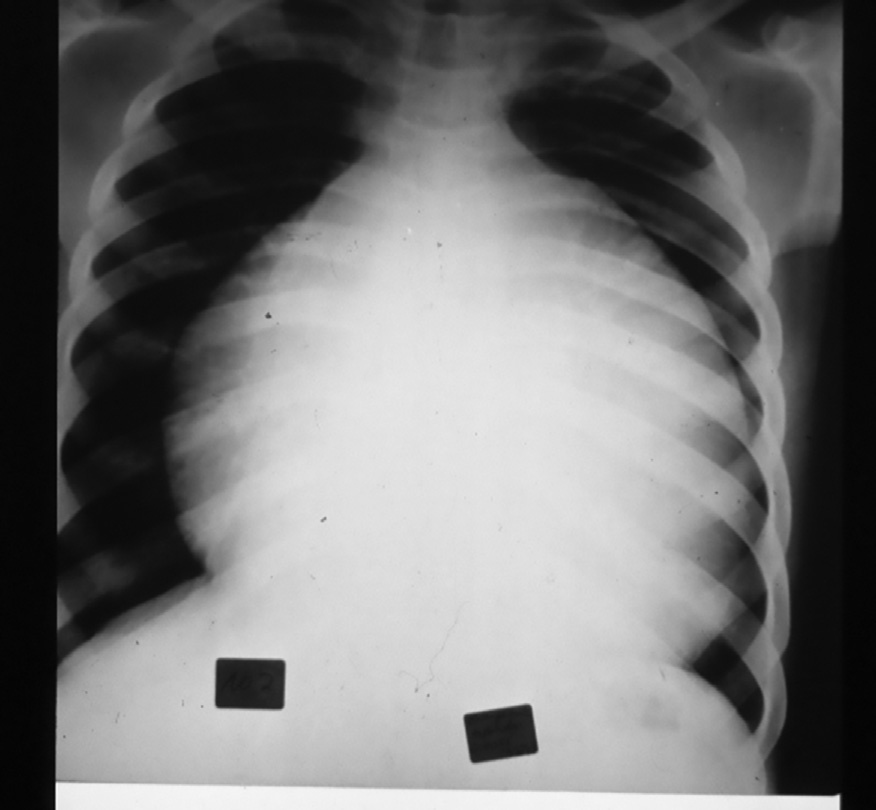

   Chest radiograph of the patient showing an enlarged globular cardiac silhouette with clear lung fields.
------------------------------
#2 — Score=0.874
📄 /kaggle/input/extracted-clinical-dataset/extracted_json/91---A-20-Year-Old-Male-from-India-With-Fever-_2022_Clinical-Cases-in-Tropic.json
🩸 Final Diagnosis: Paralytic rabies.. Differential Diagnosis: Guillain Barré Syndrome, Post-vaccination encephalomyelitis, NMDAR antibody-mediated/Autoimmune encephalitis, Campylobacter-associated summe...
------------------------------
#3 — Score=0.873
📄 /kaggle/input/extracted-clinical-dataset/extracted_json/89---A-30-Year-Old-Woman-from-Bolivia-With-Ex_2022_Clinical-Cases-in-Tropica.json
🩸 Final Diagnosis: Chagas disease with chagasic cardiomyopathy.. Differential Diagnosis: Screening for active and latent tuberculosis, HIV, hepatitis B, hepatitis C, strongyloidiasis, and Chagas disease...


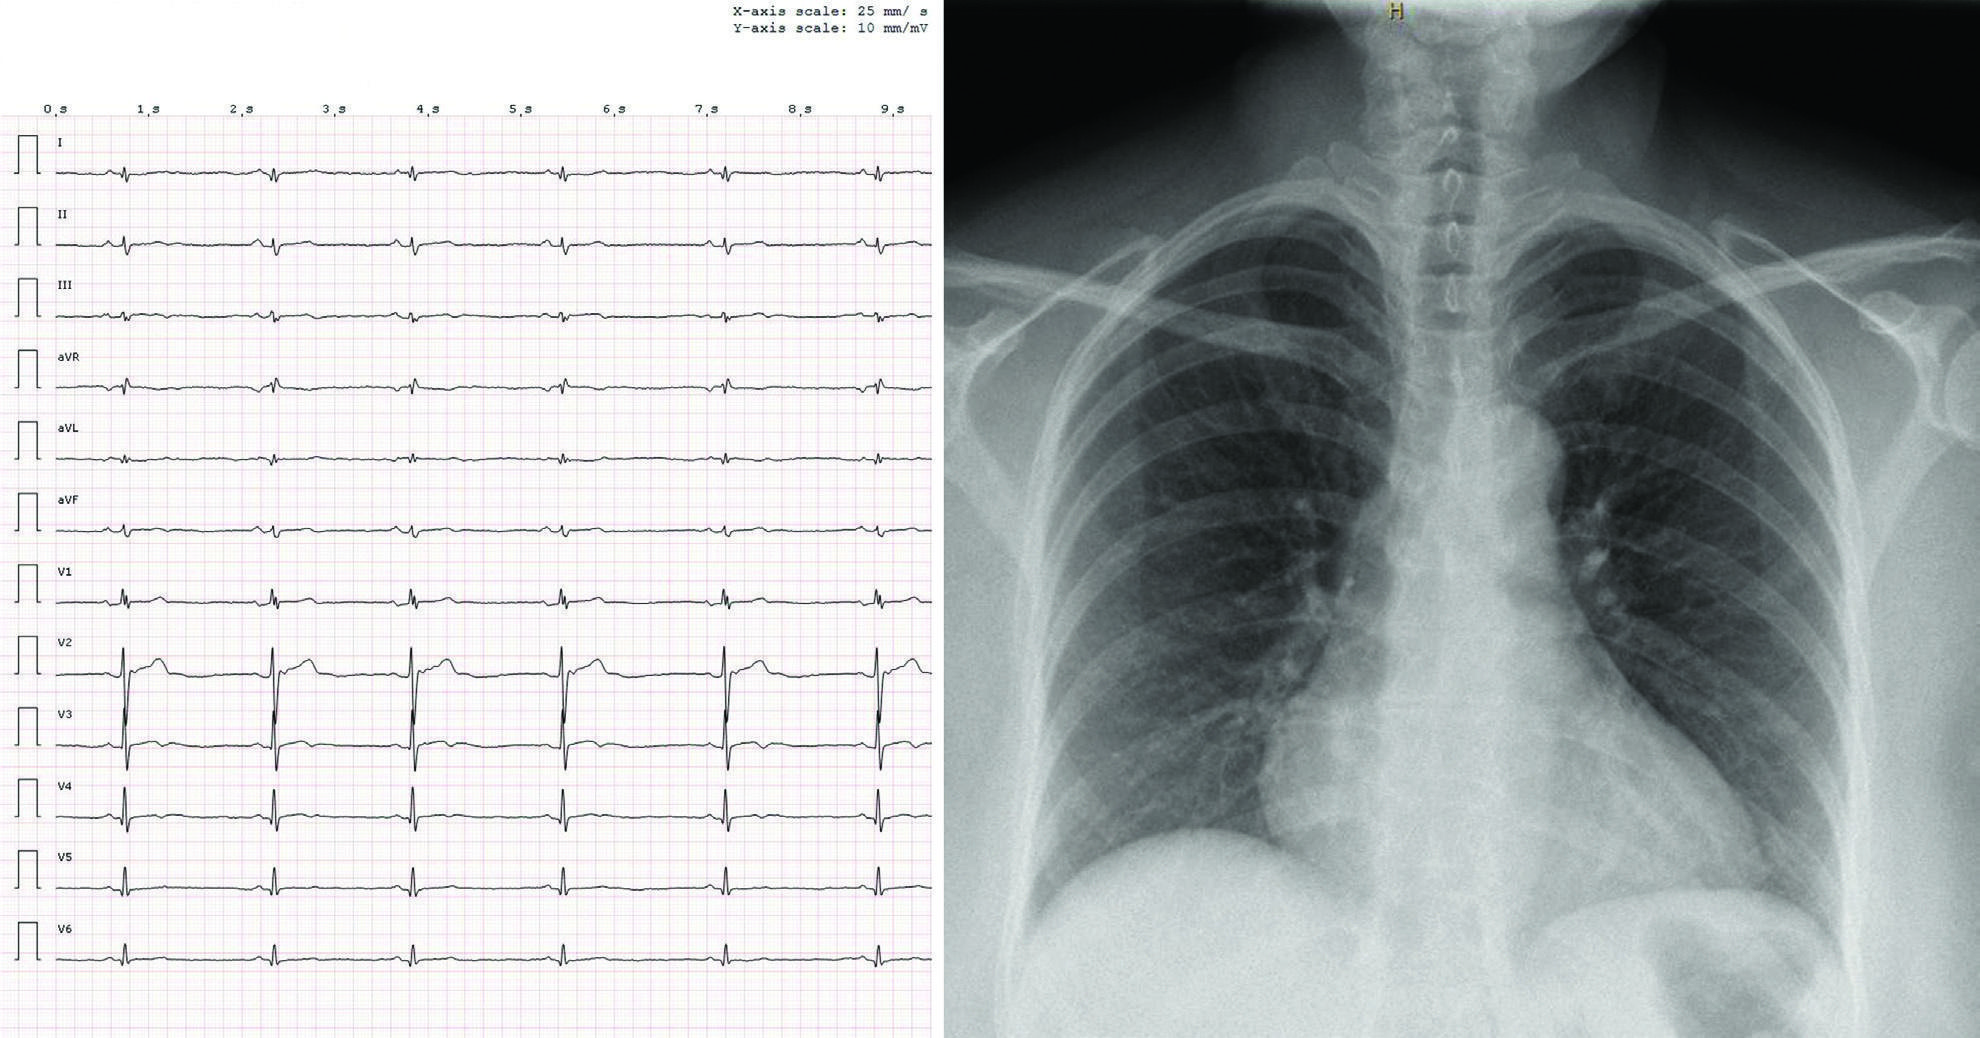

   ECG showing sinus bradycardia with right bundle branch block. CXR showing a moderately enlarged cardiac silhouette.


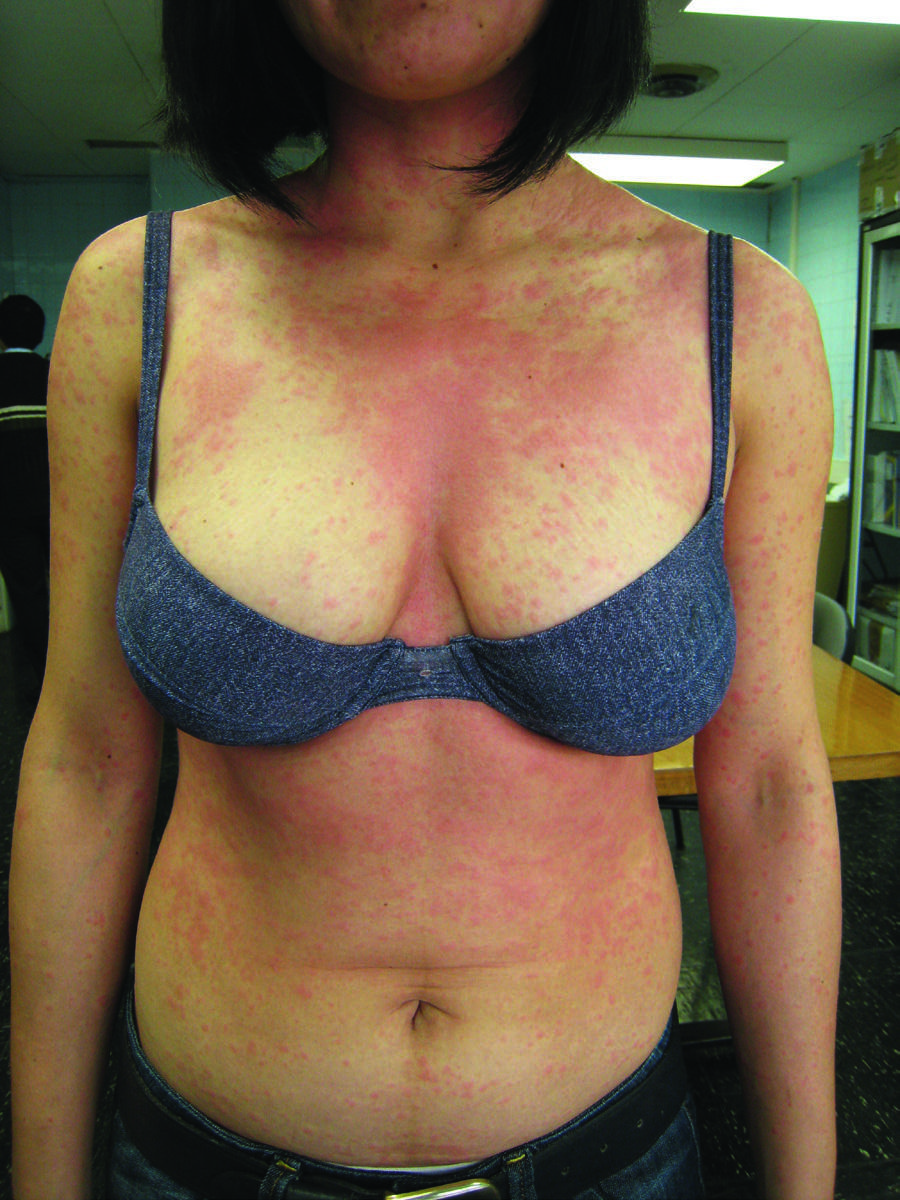

   Maculopapular rash with pruritus after 15 days on benznidazole.
------------------------------


[(84,
  0.8778876,
  {'file': '/kaggle/input/extracted-clinical-dataset/extracted_json/66---A-32-Year-Old-Man-from-Malawi-With-Pain-in-the-_2022_Clinical-Cases-in-.json',
   'text': "Final Diagnosis: HIV-associated tuberculous pericardial effusion with cardiac tamponade.. Differential Diagnosis: Pericardial tamponade caused by a large pericardial effusion. Causes considered in Africa include tuberculosis, other bacterial infections, malignancy, and HIV-related Kaposi's sarcoma. HIV-associated tuberculosis was deemed the most likely diagnosis given the history of herpes zoster.. Management And Clinical Course: The patient underwent therapeutic pericardial aspiration, with 500 mL of bloodstained pericardial fluid aspirated, leading to an immediate increase in blood pressure to 120/80 mmHg. He was started on standard first-line antituberculous treatment (rifampicin, isoniazid, pyrazinamide, and ethambutol) daily, along with prednisolone 60 mg daily. After confirmation of HIV-positive stat

In [9]:
# =========================================================
# 🧠 Clinical Search with Image Display  
# =========================================================
def search_with_images(query_text: str, k: int = 5):
    """Search clinical FAISS index and display retrieved images."""
    if not len(metadata):
        return

    # Build text embeddings
    bio_q = embed_bio_text(query_text) if query_text else np.zeros((1, bio_dim), dtype="float32")
    clip_text_q = embed_clip_text(query_text) if query_text else np.zeros((1, clip_text_dim), dtype="float32")

    # Weighted fusion
    clip_img_q = np.zeros((1, clip_image_dim), dtype="float32")
    fused_q = np.hstack([
        2.0 * bio_q,
        0.75 * clip_text_q,
        0.25 * clip_img_q
    ])
    fused_q /= max(np.linalg.norm(fused_q), 1e-6)

    # FAISS search
    D, I = index.search(fused_q, k)

    # Display results
    results = []
    for rank, (idx, emb_score) in enumerate(zip(I[0], D[0]), start=1):
        entry = metadata[idx]
        results.append((idx, emb_score, entry))
        print(f"#{rank} — Score={emb_score:.3f}")
        print(f"📄 {entry['file']}")
        print(f"🩸 {entry['text'][:200]}...")
        
        # Display images if available
        images = entry.get('images', [])
        if images:
            for img_info in images[:2]:  # Limit to 2 images
                img_path = Path("/kaggle/input/extracted-clinical-dataset") / img_info.get('file_name', '')
                if img_path.exists():
                    try:
                        pil_img = Image.open(img_path)
                        display(pil_img)
                        caption = img_info.get('caption', 'No caption')
                        print(f"   {caption}")
                    except Exception as e:
                        continue
        print("-"*30)

    return results

# Test search
search_with_images("A man breathless in the supine position with pulsus paradoxus", k=3)

# ⚙️ Step 4: Augumentation and Generation 



In [10]:
import gc
import torch
from transformers import BitsAndBytesConfig, LlavaProcessor, LlavaForConditionalGeneration

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

# LLaVA model setup
LLAVA_ID = "llava-hf/llava-v1.6-mistral-7b-hf"

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load processor + model
llava_processor = LlavaProcessor.from_pretrained(LLAVA_ID)
llava_model = LlavaForConditionalGeneration.from_pretrained(
    LLAVA_ID,
    quantization_config=bnb_cfg,
    device_map="auto",
    torch_dtype=torch.float16
)
llava_model.eval()

Device: cuda


preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affi

In [ ]:
# =========================================================
# STEP 4 — Four Generation Variants (Updated)
# =========================================================
import json, re, gc, faiss, torch, time
from pathlib import Path
from PIL import Image
from transformers import (
    AutoProcessor, AutoModel,
    LlavaProcessor, LlavaForConditionalGeneration,
    BitsAndBytesConfig
)

# Paths 
BASE_DATA = Path("/kaggle/input/extracted-clinical-dataset/extracted structured data/extracted data")
JSON_DIR = BASE_DATA / "/extracted_json/extracted_json"
IMG_DIR = BASE_DATA / "/extracted_images/extracted_images"

RAG_OUTPUT_DIR = Path("/kaggle/working/output")
FAISS_INDEX_PATH = RAG_OUTPUT_DIR / "medclip_index.faiss"
METADATA_PATH = RAG_OUTPUT_DIR / "medclip_metadata.json"

# Load FAISS + metadata
index = faiss.read_index(str(FAISS_INDEX_PATH))
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)
print(f"FAISS loaded: {index.ntotal} cases")

def get_text_embedding(text):
    """Compute BioClinicalBERT embedding for retrieval."""
    inputs = bio_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = bio_model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embedding / np.linalg.norm(embedding)

# =========================================================
# 🎯 VARIANT 1a: Model + Text-only (No RAG, No Image)
# =========================================================
def generate_answer_model_only(question, max_new_tokens=256, temperature=0.7):
    """Variant 1a: Pure model generation without RAG retrieval (text-only)."""
    
    prompt = f"""<|user|>:
You are a medical AI assistant. Answer the following medical question based on your training knowledge.

Question:
{question}

Answer the question directly, concisely, and precisely based on medical knowledge. Provide ONLY the required answer without including a separate diagnosis or management plan unless the question specifically asks for one.

<|assistant|>:
"""
    
    try:
        inputs = llava_processor(prompt, return_tensors="pt").to(device)
        
        with torch.no_grad():
            output = llava_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=0.9,
                do_sample=True,
                pad_token_id=llava_processor.tokenizer.eos_token_id
            )

        answer = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
        if "<|assistant|>:" in answer:
            answer = answer.split("<|assistant|>:")[-1].strip()
        
        answer = f"[Model-Only] {answer}"
        
    except Exception as e:
        answer = f"[Model-Only Error] {str(e)}"

    return answer, []

# =========================================================
# 🎯 VARIANT 1b: Model + Image (No RAG, With Image)
# =========================================================
def generate_answer_model_only_multimodal(question, query_image=None, max_new_tokens=256, temperature=0.7):
    """Variant 1b: Pure model generation with image input (no RAG retrieval)."""
    
    prompt = f"""<|user|>:
You are a medical AI assistant. Answer the following medical question based on your training knowledge and the provided medical image.

Question:
{question}

Analyze the medical image and answer the question directly, concisely, and precisely. Provide ONLY the required answer without including a separate diagnosis or management plan unless the question specifically asks for one.

<|assistant|>:
"""
    
    try:
        # Process with image
        if query_image is not None:
            inputs = llava_processor(
                text=prompt,
                images=query_image,
                return_tensors="pt"
            ).to(device)
        else:
            # Fallback to text-only if no image
            inputs = llava_processor(prompt, return_tensors="pt").to(device)
        
        with torch.no_grad():
            output = llava_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=0.9,
                do_sample=True,
                pad_token_id=llava_processor.tokenizer.eos_token_id
            )

        answer = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
        if "<|assistant|>:" in answer:
            answer = answer.split("<|assistant|>:")[-1].strip()
        
        image_status = " (with image)" if query_image is not None else " (no image)"
        answer = f"[Model-Only-Multimodal{image_status}] {answer}"
        
    except Exception as e:
        answer = f"[Model-Only-Multimodal Error] {str(e)}"

    return answer, []

# =========================================================
# 🎯 VARIANT 2: Model + RAG + Text-only (With Re-ranking)
# =========================================================
def generate_answer_rag_text_only(question, top_k_initial=10, top_k_final=5, max_new_tokens=256, temperature=0.7):
    """Variant 2: RAG-enhanced generation with re-ranking (text-only)."""
    
    # Retrieve and re-rank contexts (TEXT-ONLY)
    retrieved_docs = retrieve_and_rerank_context(question, top_k_initial, top_k_final)
    
    # Build text context from re-ranked results
    context_texts = []
    for i, doc in enumerate(retrieved_docs):
        score_info = f"[Relevance: {doc.get('combined_score', 0):.3f}]"
        retrieval_info = f"[{doc.get('retrieval_type', 'unknown')}]"
        context_text = f"[Case {i+1}] {retrieval_info} {score_info} {doc['text'][:500]}..."
        context_texts.append(context_text)
    
    context = "\n\n".join(context_texts)
    
    prompt = f"""<|user|>:
You are a medical AI assistant. Use the following re-ranked clinical cases to answer the question.
Cases are ordered by relevance score (higher = more relevant).

Re-ranked Clinical Cases:
{context}

Question:
{question}

Answer the question directly, concisely, and precisely based ONLY on the retrieved clinical information. Provide ONLY the required answer without including a separate diagnosis or management plan unless the question specifically asks for one.

<|assistant|>:
"""
    
    try:
        inputs = llava_processor(prompt, return_tensors="pt").to(device)
        
        with torch.no_grad():
            output = llava_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=0.9,
                do_sample=True,
                pad_token_id=llava_processor.tokenizer.eos_token_id
            )

        answer = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
        if "<|assistant|>:" in answer:
            answer = answer.split("<|assistant|>:")[-1].strip()
        
        answer = f"[RAG+Text-only] {answer}"
        
    except Exception as e:
        answer = f"[RAG+Text-only Error] {str(e)}"

    return answer, retrieved_docs

# =========================================================
# 🎯 VARIANT 3: Model + RAG + Multimodal (With Enhanced Re-ranking)
# =========================================================
def generate_answer_rag_multimodal(question, query_image=None, top_k_initial=10, top_k_final=5, max_new_tokens=256, temperature=0.7):
    """Variant 3: Full multimodal RAG with enhanced re-ranking and images."""
    
    # Retrieve contexts with MULTIMODAL EMBEDDINGS and re-ranking
    retrieved_docs = retrieve_context_with_images_reranked(
        query=question, 
        query_image=query_image,
        top_k_initial=top_k_initial, 
        top_k_final=top_k_final
    )
    
    # Build enhanced context with re-ranking scores
    context_texts = []
    for i, doc in enumerate(retrieved_docs):
        score_info = f"[Relevance: {doc.get('combined_score', 0):.3f}]"
        image_info = f"[Images: {len(doc['images'])}]" if doc['images'] else "[No images]"
        retrieval_info = f"[{doc.get('retrieval_type', 'unknown')}]"
        context_text = f"[Case {i+1}] {retrieval_info} {score_info} {image_info} {doc['text'][:400]}..."
        context_texts.append(context_text)
    
    context = "\n\n".join(context_texts)
    
    # Prepare images for processing
    images_to_process = []
    if query_image is not None:
        images_to_process.append(query_image)
    
    # Add first image from top re-ranked case
    if retrieved_docs and retrieved_docs[0]['images']:
        images_to_process.append(retrieved_docs[0]['images'][0])
    
    # Enhanced prompt for multimodal context
    image_context = " Medical images are available for visual analysis." if images_to_process else ""
    
    prompt = f"""<|user|>:
You are a medical AI assistant. Use the following re-ranked clinical cases to answer the question.
Cases are ordered by relevance score (higher = more relevant).
{image_context}

Re-ranked Clinical Cases:
{context}

Question:
{question}

Answer the question directly, concisely, and precisely based ONLY on the retrieved clinical information. Provide ONLY the required answer without including a separate diagnosis or management plan unless the question specifically asks for one. 
Provide a diagnosis and management plan based on the clinical information and any visual findings.

<|assistant|>:
"""
    
    try:
        # Process text and images separately for LLaVA
        if images_to_process:
            inputs = llava_processor(
                text=prompt,
                images=images_to_process,
                return_tensors="pt"
            ).to(device)
        else:
            inputs = llava_processor(
                text=prompt,
                return_tensors="pt"
            ).to(device)
        
        with torch.no_grad():
            output = llava_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=0.9,
                do_sample=True,
                pad_token_id=llava_processor.tokenizer.eos_token_id
            )

        answer = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
        if "<|assistant|>:" in answer:
            answer = answer.split("<|assistant|>:")[-1].strip()
        
        # Add multimodal context info
        multimodal_info = f" (Processed {len(images_to_process)} images)" if images_to_process else ""
        answer = f"[RAG+Multimodal{multimodal_info}] {answer}"
        
    except Exception as e:
        # Fallback to text-only
        try:
            inputs = llava_processor(prompt, return_tensors="pt").to(device)
            with torch.no_grad():
                output = llava_model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    temperature=temperature,
                    top_p=0.9,
                    do_sample=True,
                    pad_token_id=llava_processor.tokenizer.eos_token_id
                )
            
            answer = llava_processor.tokenizer.decode(output[0], skip_special_tokens=True)
            if "<|assistant|>:" in answer:
                answer = answer.split("<|assistant|>:")[-1].strip()
            answer = f"[RAG+Multimodal-Fallback] {answer}"
        except Exception as e2:
            answer = f"[RAG+Multimodal Error] {str(e2)}"

    return answer, retrieved_docs

# =========================================================
# 🎯 Comprehensive Generation Pipeline (Updated for 4 variants)
# =========================================================
def generate_all_variants(question, query_image=None, top_k_initial=10, top_k_final=5):
    """Generate answers using all four variants for comparison."""
    
    results = {}
    
    print(f"\n PROCESSING QUESTION: {question[:100]}...")
    print(f" Query image provided: {'Yes' if query_image is not None else 'No'}")
    print("="*50)
    
    # Variant 1a: Model-only (text)
    try:
        answer1, docs1 = generate_answer_model_only(question)
        results['model_only'] = {'answer': answer1, 'docs': docs1}
    except Exception as e:
        results['model_only'] = {'answer': f"Error: {e}", 'docs': []}
    
    # Variant 1b: Model-only (multimodal) - only if image provided
    if query_image is not None:
        try:
            answer1b, docs1b = generate_answer_model_only_multimodal(question, query_image)
            results['model_only_multimodal'] = {'answer': answer1b, 'docs': docs1b}
        except Exception as e:
            results['model_only_multimodal'] = {'answer': f"Error: {e}", 'docs': []}
    
    # Variant 2: RAG + Text-only
    try:
        answer2, docs2 = generate_answer_rag_text_only(question, top_k_initial, top_k_final)
        results['rag_text'] = {'answer': answer2, 'docs': docs2}
    except Exception as e:
        results['rag_text'] = {'answer': f"Error: {e}", 'docs': []}
    
    # Variant 3: RAG + Multimodal
    try:
        answer3, docs3 = generate_answer_rag_multimodal(question, query_image, top_k_initial, top_k_final)
        results['rag_multimodal'] = {'answer': answer3, 'docs': docs3}
    except Exception as e:
        results['rag_multimodal'] = {'answer': f"Error: {e}", 'docs': []}
    
    return results

FAISS loaded: 93 cases


In [ ]:
# =========================================
# 🧪 Testing All Four Generation Variants
# =========================================

# Case 70: Scrub typhus (no images)
case_question = (
    "A 58-year-old rural woman from Sri Lanka presents with a 5-day progressive illness starting with high fever, "
    "headache, and myalgia. History reveals she works in rice fields with recent exposure to scrubland vegetation. "
    "On day 2, she developed neurological symptoms including confusion, hearing loss, coarse tremors, and saccadic eye movements. "
    "Physical exam shows hepatosplenomegaly, enlarged axillary lymph nodes, and a pathognomonic crater-like eschar in the right axilla. "
    "Laboratory findings include normal WBC count, thrombocytopenia, and elevated liver enzymes. CSF analysis shows lymphocytic pleocytosis. "
    "Given the endemic area for trombiculid mite-transmitted disease and clinical presentation with eschar, "
    "what is the final diagnosis?"
)

print(f"🩺 Test Question (Case 70 - Scrub Typhus): {case_question[:100]}...")
print("="*70)

# Generate all variants (no image - should produce 3 variants)
all_results = generate_all_variants(
    question=case_question,
    query_image=None,  # NO IMAGE
    top_k_initial=8,
    top_k_final=5
)

# Display concise results
print("\n RESULTS (No Image - 3 Variants):")
print("="*70)

print("\n VARIANT 1a: Model + Text-only")
print(all_results['model_only']['answer'][:200] + "...")

print("\n VARIANT 1b: Model + Multimodal (Image)")
if 'model_only_multimodal' in all_results:
    print(all_results['model_only_multimodal']['answer'][:200] + "...")
else:
    print("⚠️ Skipped (no image provided)")

print("\n VARIANT 2: Model + RAG + Text-only")
print(all_results['rag_text']['answer'][:200] + "...")
if all_results['rag_text']['docs']:
    print(f"\n Text-Only Re-ranked Contexts ({len(all_results['rag_text']['docs'])}):")
    for i, doc in enumerate(all_results['rag_text']['docs'], 1):
        combined_score = doc.get('combined_score', 0)
        original_score = doc.get('similarity_score', 0)
        rerank_score = doc.get('rerank_score', 0)
        retrieval_type = doc.get('retrieval_type', 'unknown')
        print(f"  [{i}] Type: {retrieval_type}")
        print(f"      Original: {original_score:.3f} | Rerank: {rerank_score:.3f} | Combined: {combined_score:.3f}")

print("\n VARIANT 3: Model + RAG + Multimodal")
print(all_results['rag_multimodal']['answer'][:200] + "...")
if all_results['rag_multimodal']['docs']:
    print(f"\n Multimodal Re-ranked Contexts ({len(all_results['rag_multimodal']['docs'])}):")
    for i, doc in enumerate(all_results['rag_multimodal']['docs'], 1):
        img_count = len(doc.get('images', []))
        combined_score = doc.get('combined_score', 0)
        original_score = doc.get('similarity_score', 0)
        rerank_score = doc.get('rerank_score', 0)
        retrieval_type = doc.get('retrieval_type', 'unknown')
        print(f"  [{i}] Type: {retrieval_type}")
        print(f"      Original: {original_score:.3f} | Rerank: {rerank_score:.3f} | Combined: {combined_score:.3f} | Images: {img_count}")


You may have used the wrong order for inputs. `images` should be passed before `text`. The `images` and `text` inputs will be swapped. This behavior will be deprecated in transformers v4.47.


🩺 Test Question (Case 70 - Scrub Typhus): A 58-year-old rural woman from Sri Lanka presents with a 5-day progressive illness starting with hig...

 PROCESSING QUESTION: A 58-year-old rural woman from Sri Lanka presents with a 5-day progressive illness starting with hig...
 Query image provided: No

 RESULTS:

 VARIANT 1: Model + Text-only
[Model-Only] The final diagnosis is scrub typhus....

 VARIANT 2: Model + RAG + Text-only
[RAG+Text-only] The final diagnosis is Scrub Typhus, supported by a high O. tsutsugamushi IFA-IgG titre (>1:4096) and a crater-like eschar in the right axilla....

 Text-Only Re-ranked Contexts (5):
  [1] Type: text-only
      Original: 0.890 | Rerank: -6.295 | Combined: -1.265
  [2] Type: text-only
      Original: 0.895 | Rerank: -7.054 | Combined: -1.490
  [3] Type: text-only
      Original: 0.892 | Rerank: -7.265 | Combined: -1.555
  [4] Type: text-only
      Original: 0.899 | Rerank: -7.518 | Combined: -1.626
  [5] Type: text-only
      Original: 0.895 | Rera

 Loaded: page2_img1.jpeg


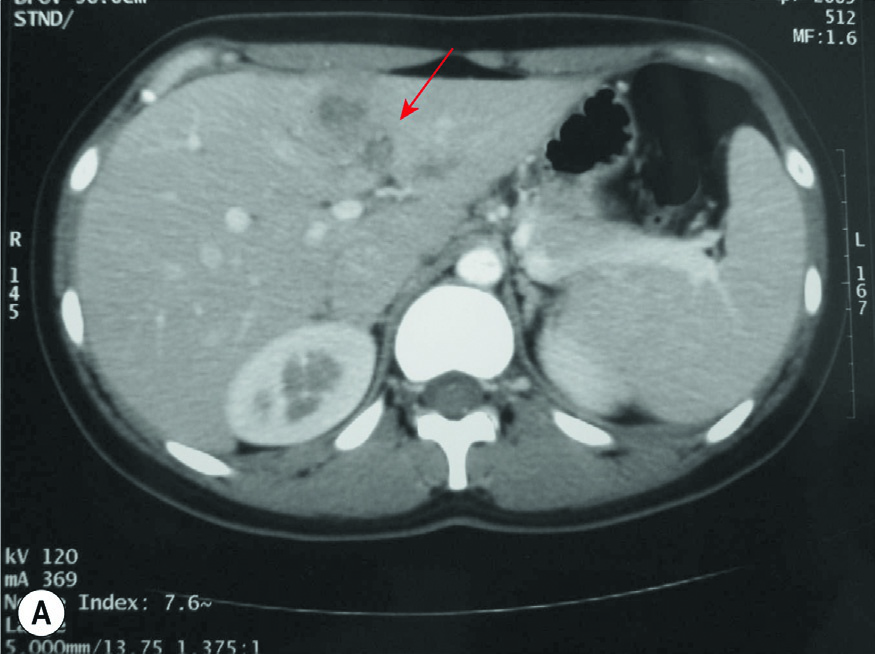


🩺 Question (Case 67 - Fasciola hepatica with CT images): A 24-year-old woman from the Peruvian Andes presents with 2 months of upper abdominal pain, 5 kg weight loss, nausea, vomiting, and 2 weeks of intermittent fevers. She has been consuming vegetarian foods including watercress and alfalfa drinks. Physical exam shows right upper quadrant tenderness and hepatomegaly (15 cm span). Laboratory shows marked eosinophilia (43%, total 5.97), elevated alkaline phosphatase (170 U/L), and multiple hypodense liver lesions on CT scan. What is the most likely diagnosis?

 PROCESSING QUESTION: A 24-year-old woman from the Peruvian Andes presents with 2 months of upper abdominal pain, 5 kg wei...
 Query image provided: Yes

 MULTIMODAL RESULTS WITH RETRIEVAL ANALYSIS:

 VARIANT 1: Model + Text-only
[Model-Only] The most likely diagnosis is celiac disease....

 VARIANT 2: Model + RAG + Text-only
[RAG+Text-only] The most likely diagnosis for this patient is fascioliasis due to Fasciola hepatica....


In [ ]:
# =========================================================
# 🧪 Advanced Test: Multimodal Case with Detailed Analysis
# =========================================================

# Load query image from Fasciola hepatica case (Case 67)
query_image_path = Path("/kaggle/input/extracted-clinical-dataset/extracted_images/67---A-24-Year-Old-Woman-from-the-Peruvian-Andes-_2022_Clinical-Cases-in-Tro/page2_img1.jpeg")

query_image = None
if query_image_path.exists():
    query_image = Image.open(query_image_path).convert("RGB")
    print(f" Loaded: {query_image_path.name}")
    display(query_image)
else:
    print(f" Image not found")

# Fasciola hepatica test case (Case 67)
case_question = (
    "A 24-year-old woman from the Peruvian Andes presents with 2 months of upper abdominal pain, "
    "5 kg weight loss, nausea, vomiting, and 2 weeks of intermittent fevers. She has been consuming "
    "vegetarian foods including watercress and alfalfa drinks. Physical exam shows right upper quadrant "
    "tenderness and hepatomegaly (15 cm span). Laboratory shows marked eosinophilia (43%, total 5.97), "
    "elevated alkaline phosphatase (170 U/L), and multiple hypodense liver lesions on CT scan. "
    "What is the most likely diagnosis?"
)

print(f"\n🩺 Question (Case 67 - Fasciola hepatica with CT images): {case_question}")
print("="*70)

# Test all variants (with image - should produce 4 variants)
multimodal_results = generate_all_variants(
    question=case_question,
    query_image=query_image,
    top_k_initial=10,
    top_k_final=5
)

# Results with detailed analysis
print("\n MULTIMODAL RESULTS WITH RETRIEVAL ANALYSIS (4 Variants):")
print("="*70)

print("\n VARIANT 1a: Model + Text-only")
print(multimodal_results['model_only']['answer'][:200] + "...")

print("\n VARIANT 1b: Model + Multimodal (Image)")
if 'model_only_multimodal' in multimodal_results:
    print(multimodal_results['model_only_multimodal']['answer'][:200] + "...")
else:
    print("⚠️ Skipped (no image provided)")

print("\n VARIANT 2: Model + RAG + Text-only")
print(multimodal_results['rag_text']['answer'][:200] + "...")
if multimodal_results['rag_text']['docs']:
    print(f"\n Text-Only Re-ranked Contexts ({len(multimodal_results['rag_text']['docs'])}):")
    for i, doc in enumerate(multimodal_results['rag_text']['docs'], 1):
        combined_score = doc.get('combined_score', 0)
        original_score = doc.get('similarity_score', 0)
        rerank_score = doc.get('rerank_score', 0)
        retrieval_type = doc.get('retrieval_type', 'unknown')
        print(f"  [{i}] Type: {retrieval_type}")
        print(f"      Original: {original_score:.3f} | Rerank: {rerank_score:.3f} | Combined: {combined_score:.3f}")

print("\n VARIANT 3: Model + RAG + Multimodal")
print(multimodal_results['rag_multimodal']['answer'][:200] + "...")
if multimodal_results['rag_multimodal']['docs']:
    print(f"\n Multimodal Re-ranked Contexts ({len(multimodal_results['rag_multimodal']['docs'])}):")
    for i, doc in enumerate(multimodal_results['rag_multimodal']['docs'], 1):
        img_count = len(doc.get('images', []))
        combined_score = doc.get('combined_score', 0)
        original_score = doc.get('similarity_score', 0)
        rerank_score = doc.get('rerank_score', 0)
        retrieval_type = doc.get('retrieval_type', 'unknown')
        print(f"  [{i}] Type: {retrieval_type}")
        print(f"      Original: {original_score:.3f} | Rerank: {rerank_score:.3f} | Combined: {combined_score:.3f} | Images: {img_count}")

print("\n"+ "="*70)
print("📊 VARIANT SUMMARY FOR THIS CASE:")
print(f"  • Total variants generated: {len([k for k in multimodal_results.keys() if 'answer' in multimodal_results[k]])}")
print(f"  • Image-based variants: 2 (model_only_multimodal + rag_multimodal)")
print(f"  • Text-only variants: 2 (model_only + rag_text)")


In [ ]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# Load questions file from updated path
with open(Path("/kaggle/input/ngocdataset/high_relevance_questions_multi.json"), "r", encoding="utf-8") as f:
    qa_pairs = json.load(f)

MAX_CASES_TO_EVALUATE = len(qa_pairs)
num_cases_to_run = min(len(qa_pairs), MAX_CASES_TO_EVALUATE)
qa_pairs_subset = qa_pairs[:num_cases_to_run]

all_generated_outputs = []

for i, qa in enumerate(tqdm(qa_pairs_subset, desc="Generating Answers")):
    qid = str(qa.get("qa_id", f"auto_{i}"))
    question = qa.get("question", "")
    ground_truth = qa.get("answer", "")
    image_path = qa.get("image_path", None)
    
    # Load image if provided (for multimodal variants)
    query_image = None
    if image_path:
        try:
            # Use image_path directly since it already contains the full path
            full_image_path = Path(image_path)
            if full_image_path.exists():
                query_image = Image.open(full_image_path).convert("RGB")
                print(f"  ✓ Loaded image: {image_path}")
            else:
                print(f"  ⚠ Image not found: {full_image_path}")
        except Exception as e:
            print(f"  ⚠ Warning: Could not load image {image_path}: {e}")
    
    # --- Generate FOUR variants based on image availability ---
    
    # Variant 1a: Model-only (text) - ALWAYS generate for ALL questions
    answer, docs = generate_answer_model_only(question)
    all_generated_outputs.append({
        "id": f"{qid}_model_only",
        "qa_id": qid,
        "variant": "model_only",
        "question": question,
        "answer": answer,
        "ground_truth": ground_truth,
        "retrieved_context": [d['text'] for d in docs] if docs else [],
        "num_retrieved_docs": len(docs) if docs else 0,
        "image_used": False,
        "image_path": image_path if image_path else None
    })
    
    # Variant 1b: Model-only (multimodal) - ONLY if image_path exists AND image loaded
    if image_path and query_image is not None:
        answer, docs = generate_answer_model_only_multimodal(question, query_image)
        all_generated_outputs.append({
            "id": f"{qid}_model_only_multimodal",
            "qa_id": qid,
            "variant": "model_only_multimodal",
            "question": question,
            "answer": answer,
            "ground_truth": ground_truth,
            "retrieved_context": [d['text'] for d in docs] if docs else [],
            "num_retrieved_docs": len(docs) if docs else 0,
            "image_used": True,
            "image_path": image_path
        })
    
    # Variant 2: RAG + Text-only (no images) - ALWAYS generate for ALL questions
    answer, docs = generate_answer_rag_text_only(question)
    all_generated_outputs.append({
        "id": f"{qid}_rag_text",
        "qa_id": qid,
        "variant": "rag_text_reranked",
        "question": question,
        "answer": answer,
        "ground_truth": ground_truth,
        "retrieved_context": [d['text'] for d in docs] if docs else [],
        "num_retrieved_docs": len(docs) if docs else 0,
        "image_used": False,
        "image_path": image_path if image_path else None
    })
    
    # Variant 3: RAG + Multimodal (with images) - ONLY if image_path exists AND image loaded
    if image_path and query_image is not None:
        answer, docs = generate_answer_rag_multimodal(
            question,
            query_image=query_image
        )
        all_generated_outputs.append({
            "id": f"{qid}_rag_multimodal",
            "qa_id": qid,
            "variant": "rag_multimodal",
            "question": question,
            "answer": answer,
            "ground_truth": ground_truth,
            "retrieved_context": [d['text'] for d in docs] if docs else [],
            "num_retrieved_docs": len(docs) if docs else 0,
            "image_used": True,
            "image_path": image_path
        })

# --- Final Save to JSON ---
df_output = pd.DataFrame(all_generated_outputs)
JSON_OUTPUT_PATH = "generation_outputs_for_evaluation_multi.json"

# Convert the DataFrame to a list of records (JSON format)
results_list = df_output.to_dict(orient='records')

# Save the list to a JSON file
with open(JSON_OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(results_list, f, indent=4, ensure_ascii=False)

print(f"\n{'='*70}")
print(f"✅ Completed generation for {len(results_list)} total entries")
print(f"📊 Saved to {JSON_OUTPUT_PATH}")
print(f"\nBreakdown by variant:")
for variant in ['model_only', 'model_only_multimodal', 'rag_text_reranked', 'rag_multimodal']:
    count = len([r for r in results_list if r['variant'] == variant])
    if count > 0:
        print(f"  • {variant}: {count} entries")

# Summary statistics
text_only_count = len([r for r in results_list if r['variant'] == 'model_only'])
multimodal_model_count = len([r for r in results_list if r['variant'] == 'model_only_multimodal'])
rag_text_count = len([r for r in results_list if r['variant'] == 'rag_text_reranked'])
rag_multimodal_count = len([r for r in results_list if r['variant'] == 'rag_multimodal'])

print(f"\n📊 Expected Output Distribution:")
print(f"  • model_only (text): {text_only_count} / 84 ✓")
print(f"  • model_only_multimodal (image): {multimodal_model_count} / 18 ✓")
print(f"  • rag_text_reranked: {rag_text_count} / 84 ✓")
print(f"  • rag_multimodal: {rag_multimodal_count} / 18 ✓")
print(f"  • Total: {len(results_list)} / 204 ✓")


Generating Answers:   0%|          | 0/84 [00:00<?, ?it/s]

  ✓ Loaded image: /kaggle/input/ngoc-extracted/extracted-images/i087.jpg


Generating Answers:   1%|          | 1/84 [00:22<30:56, 22.36s/it]

  ✓ Loaded image: /kaggle/input/ngoc-extracted/extracted-images/i087.jpg


Generating Answers:   2%|▏         | 2/84 [00:58<41:19, 30.24s/it]

...

  ✓ Loaded image: /kaggle/input/ngoc-extracted/extracted-images/i148.jpg


Generating Answers:  42%|████▏     | 35/84 [10:46<19:07, 23.42s/it]

  ✓ Loaded image: /kaggle/input/ngoc-extracted/extracted-images/i148.jpg


Generating Answers: 100%|██████████| 84/84 [21:31<00:00, 15.38s/it]


✅ Completed generation for 186 total entries
📊 Saved to generation_outputs_for_evaluation_multi.json

Breakdown by variant:
  • model_only: 84 entries
  • rag_text_reranked: 84 entries
  • rag_multimodal: 18 entries

📸 Multimodal questions with images: 18
